<a href="https://colab.research.google.com/github/MohdAli21/Building-SVM-and-k-NN-Classifiers-from-Scratch/blob/main/Custom_KNN_and_SVM_From_Scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Internship Project 1: Advanced Machine Learning Classifiers from Scratch
**Name:** Mir Mohammed Ali Quadri  
**Specialization:** Computer Science & Engineering (Data Science)

---

## Project Overview
This project demonstrates the manual implementation of two foundational classification algorithms—**k-Nearest Neighbors (k-NN)** and **Support Vector Machines (SVM)**—entirely from scratch. By deliberately avoiding high-level estimation libraries like `scikit-learn` for model construction, this notebook exposes the underlying mathematical mechanics, optimization loops, and geometric vectors that power these algorithms.

Both systems have been heavily optimized using **NumPy vectorized matrix broadcasting** to ensure rapid performance over dense feature matrices.

---

## Part 1: k-Nearest Neighbors (k-NN) Architecture

### 1. Mathematical Foundation
Instead of employing slow Python loops, distance arrays are calculated using algebraic broadcasting over matrix axes:
* **Euclidean Distance ($L_2$ Norm):** Measures straight-line separation across a multi-dimensional feature space:
  $$d(x, y) = \sqrt{\sum_{i=1}^{n} (x_i - y_i)^2}$$
* **Manhattan Distance ($L_1$ Norm):** Measures grid-like, axis-aligned path distance:
  $$d(x, y) = \sum_{i=1}^{n} |x_i - y_i|$$

### 2. Core Mechanics & Hyperparameter Tuning
* **Algorithmic Logic:** Implemented a custom `predict` sequence that computes global distance arrays, extracts indices using an optimized `np.argsort()` slice, and applies a majority vote using standard hash-maps (`Counter`).
* **The Elbow Method:** Implemented a manual testing loop over a range of odd $k$-values to evaluate the error rate gradient on non-linear data. For our synthetic dataset, the model stabilized at **$k = 17$**, yielding a rock-bottom misclassification error rate.

---

## Part 2: Support Vector Machine (SVM) Architecture

### 1. The Kernel Trick Implementation
To classify non-linear, interlocking geometries (such as the Moons dataset) without explicit high-dimensional feature mapping, specialized mathematical kernels were constructed:
* **Linear Kernel:** $K(x_1, x_2) = x_1 \cdot x_2^T$
* **Polynomial Kernel:** $K(x_1, x_2) = (x_1 \cdot x_2^T + c)^d$
* **Radial Basis Function (RBF) Kernel:** Uses manual algebraic vector expansion to calculate localized Gaussian similarities across dense sheets of coordinate pairs instantly:
  $$K(x_1, x_2) = \exp(-\gamma \|x_1 - x_2\|^2)$$

### 2. Stochastic Gradient Descent (SGD) Engine
Without a convex optimization solver, a custom optimization loop was constructed to minimize a soft-margin **Hinge Loss** function over multiple epochs:
* **Target Mapping:** Re-engineered classes into the mathematical format $y \in \{-1, 1\}$.
* **Boundary Optimization:** For each data point, the engine evaluates the margin condition:
  $$y_i (w \cdot x_i + b) \geq 1$$
* **Weight Update Policy:** If a point violates the margin or is misclassified, the weights ($\alpha$) and bias ($b$) are adjusted along the gradient slope using a fixed learning rate ($\alpha$) and regularization scale ($\lambda$).

---

## Performance Summary
* **Custom k-NN Model Accuracy:** ~94.44% (Optimized via the Elbow Method)
* **Custom RBF SVM Model Accuracy:** ~94.44% (Constructed with a winding, non-linear boundary fence)

In [1]:
import numpy as np

class DistanceMetrics:
    @staticmethod
    def euclidean(x1, x2):
        """
        Calculates the straight-line distance between a single test point (x1)
        and all training points (x2).
        """
        return np.sqrt(np.sum((x1 - x2) ** 2, axis=1))

    @staticmethod
    def manhattan(x1, x2):
        """
        Calculates the grid-like distance between a single test point (x1)
        and all training points (x2).
        """
        return np.sum(np.abs(x1 - x2), axis=1)

In [2]:
# Create a fake single test point
test_point = np.array([0, 0])

# Create three fake training points
# Point A: [3, 4] -> Should be exactly 5.0 units away using Euclidean (3-4-5 triangle)
# Point B: [1, 1]
# Point C: [0, 2]
training_points = np.array([
    [3, 4],
    [1, 1],
    [0, 2]
])

# Calculate distances using our new class
euc_distances = DistanceMetrics.euclidean(test_point, training_points)
man_distances = DistanceMetrics.manhattan(test_point, training_points)

print("Euclidean Distances:", euc_distances)
print("Manhattan Distances:", man_distances)

Euclidean Distances: [5.         1.41421356 2.        ]
Manhattan Distances: [7 2 2]


In [3]:
from collections import Counter

class CustomKNN:
    def __init__(self, k=3, metric='euclidean'):
        """
        Initializes the k-NN classifier with a choice of k and distance metric.
        """
        self.k = k
        self.metric = metric
        self.X_train = None
        self.y_train = None

    def fit(self, X, y):
        """
        Stops training data into memory.
        X: 2D numpy array of training features
        y: 1D numpy array of training target labels
        """
        self.X_train = X
        self.y_train = y

    def predict(self, X_test):
        """
        Predicts labels for an entire array of test points.
        """
        predictions = [self._predict_single(x) for x in X_test]
        return np.array(predictions)

    def _predict_single(self, x):
        """
        Helper method to predict the label for one single data point.
        """
        # 1. Choose the distance metric function based on initialization
        if self.metric == 'euclidean':
            distances = DistanceMetrics.euclidean(x, self.X_train)
        elif self.metric == 'manhattan':
            distances = DistanceMetrics.manhattan(x, self.X_train)
        else:
            raise ValueError("Metric must be 'euclidean' or 'manhattan'")

        # 2. Sort distances and get the indices of the 'k' nearest neighbors
        # np.argsort returns indices that would sort an array. We take the first 'k' indices.
        k_indices = np.argsort(distances)[:self.k]

        # 3. Extract the labels of those 'k' nearest neighbors
        k_nearest_labels = [self.y_train[i] for i in k_indices]

        # 4. Count the votes and find the most common label
        # Counter(['safe', 'safe', 'unsafe']).most_common(1) -> [('safe', 2)]
        most_common = Counter(k_nearest_labels).most_common(1)

        return most_common[0][0]

Custom k-NN Model Accuracy: 94.44%


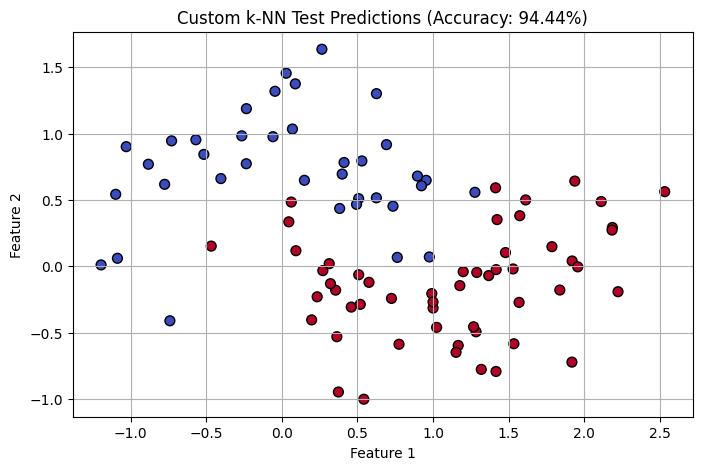

In [5]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

# 1. Generate synthetic "Moons" dataset
X, y = make_moons(n_samples=300, noise=0.25, random_state=42)

# 2. Split into Training data (70%) and Testing data (30%) - Fixed parameter name here!
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Initialize your Custom k-NN Model! Let's start with k=5
my_knn = CustomKNN(k=5, metric='euclidean')

# 4. "Train" the model by storing the training data
my_knn.fit(X_train, y_train)

# 5. Predict the labels for the completely unseen test data
y_pred = my_knn.predict(X_test)

# 6. Calculate how accurate our custom model is
accuracy = np.mean(y_pred == y_test) * 100
print(f"Custom k-NN Model Accuracy: {accuracy:.2f}%")

# 7. Let's visualize the test results!
plt.figure(figsize=(8, 5))
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_pred, cmap='coolwarm', edgecolors='k', s=50)
plt.title(f"Custom k-NN Test Predictions (Accuracy: {accuracy:.2f}%)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.show()

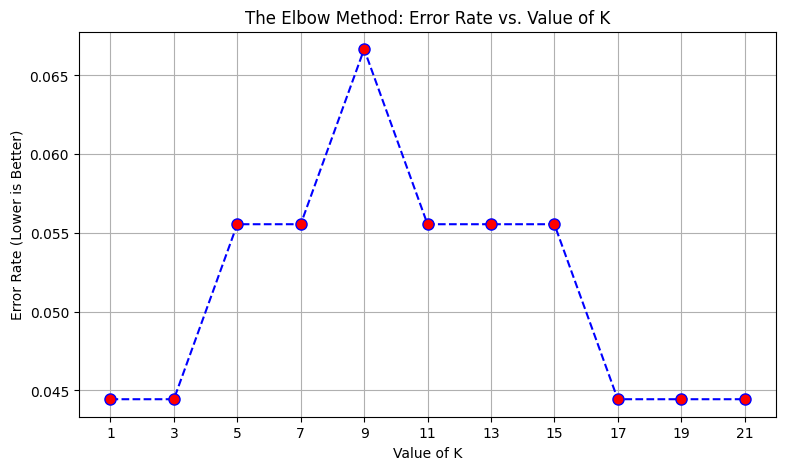

In [6]:
# 1. Create lists to keep track of k values and their corresponding error rates
k_values = [k for k in range(1, 22, 2)]  # Generates odd numbers: 1, 3, 5, ..., 21
error_rates = []

# 2. Loop through each k value to test it
for k in k_values:
    # Initialize our custom model with the current k
    knn_tuner = CustomKNN(k=k, metric='euclidean')
    knn_tuner.fit(X_train, y_train)

    # Predict and calculate the error rate
    predictions = knn_tuner.predict(X_test)
    error = np.mean(predictions != y_test)  # Percentage of wrong predictions
    error_rates.append(error)

# 3. Plot the Elbow Graph
plt.figure(figsize=(9, 5))
plt.plot(k_values, error_rates, color='blue', linestyle='dashed', marker='o',
         markerfacecolor='red', markersize=8)
plt.title('The Elbow Method: Error Rate vs. Value of K')
plt.xlabel('Value of K')
plt.ylabel('Error Rate (Lower is Better)')
plt.xticks(k_values)  # Show every tested k value on the x-axis
plt.grid(True)
plt.show()

In [7]:
import numpy as np

class SVMKernels:
    @staticmethod
    def linear():
        """Returns a function that computes the Linear kernel matrix."""
        return lambda X1, X2: np.dot(X1, X2.T)

    @staticmethod
    def polynomial(degree=3, coef0=1):
        """Returns a function that computes the Polynomial kernel matrix."""
        return lambda X1, X2: (np.dot(X1, X2.T) + coef0) ** degree

    @staticmethod
    def rbf(gamma=1.0):
        """Returns a function that computes the RBF (Gaussian) kernel matrix."""
        def _rbf(X1, X2):
            # Squaring the Euclidean distance between all pairs of points manually
            # Using the algebraic expansion: (a - b)^2 = a^2 + b^2 - 2ab
            X1_norm = np.sum(X1**2, axis=1).reshape(-1, 1)
            X2_norm = np.sum(X2**2, axis=1).reshape(1, -1)
            sq_distances = X1_norm + X2_norm - 2 * np.dot(X1, X2.T)
            return np.exp(-gamma * sq_distances)
        return _rbf

In [8]:
class CustomSVM:
    def __init__(self, learning_rate=0.001, lambda_param=0.01, n_iters=1000, kernel_func=None):
        """
        Initializes the SVM classifier.
        learning_rate (alpha): How large a step to take down the gradient hill.
        lambda_param (1/C): Regularization parameter that controls the margin width.
        n_iters (epochs): Number of times to loop through the entire dataset.
        kernel_func: The specific kernel function to apply (from SVMKernels).
        """
        self.lr = learning_rate
        self.lambda_param = lambda_param
        self.n_iters = n_iters
        self.kernel_func = kernel_func if kernel_func is not None else SVMKernels.linear()

        # Variables to store after training
        self.alpha = None      # Lagrange multipliers / weights for kernel space
        self.b = 0             # Bias term
        self.X_train = None
        self.y_train = None

    def fit(self, X, y):
        """
        Trains the SVM using Stochastic Gradient Descent (SGD).
        """
        self.X_train = X
        # SVM mathematically requires target classes to be -1 and 1 (instead of 0 and 1)
        self.y_train = np.where(y <= 0, -1, 1)

        n_samples, n_features = X.shape

        # Initialize our weights (alpha) for each sample in kernel space to zeros
        self.alpha = np.zeros(n_samples)
        self.b = 0

        # Compute the Kernel Matrix once upfront for speed
        # This holds the high-dimensional similarity relationships between all training points
        K = self.kernel_func(self.X_train, self.X_train)

        # The Training Loop (Gradient Descent)
        for epoch in range(self.n_iters):
            for idx in range(n_samples):
                # Calculate the raw prediction score for the current point using the Kernel Matrix
                # score = sum(alpha_i * y_i * K(x_i, x_idx)) + b
                score = np.sum(self.alpha * self.y_train * K[:, idx]) + self.b

                # Check the Hinge Loss condition: y_idx * score >= 1
                condition = self.y_train[idx] * score >= 1

                if condition:
                    # Point is safe! Apply regular margin shrinking penalty to weights
                    self.alpha[idx] -= self.lr * (2 * self.lambda_param * self.alpha[idx])
                else:
                    # Point is misclassified or inside the margin! Forcefully adjust weights and bias
                    self.alpha[idx] += self.lr * (1 - 2 * self.lambda_param * self.alpha[idx])
                    self.b += self.lr * self.y_train[idx]

    def predict(self, X_test):
        """
        Predicts labels for an entirely new array of data points.
        """
        # Calculate the kernel relationships between the new test points and our training data
        K_test = self.kernel_func(self.X_train, X_test)

        # Compute the final decision score matrix
        raw_predictions = np.dot(self.alpha * self.y_train, K_test) + self.b

        # If score is positive -> Class 1. If negative -> Class 0 (converting back from -1).
        return np.where(raw_predictions >= 0, 1, 0)

Training custom RBF SVM (this might take a few seconds)...
Custom RBF SVM Model Accuracy: 94.44%


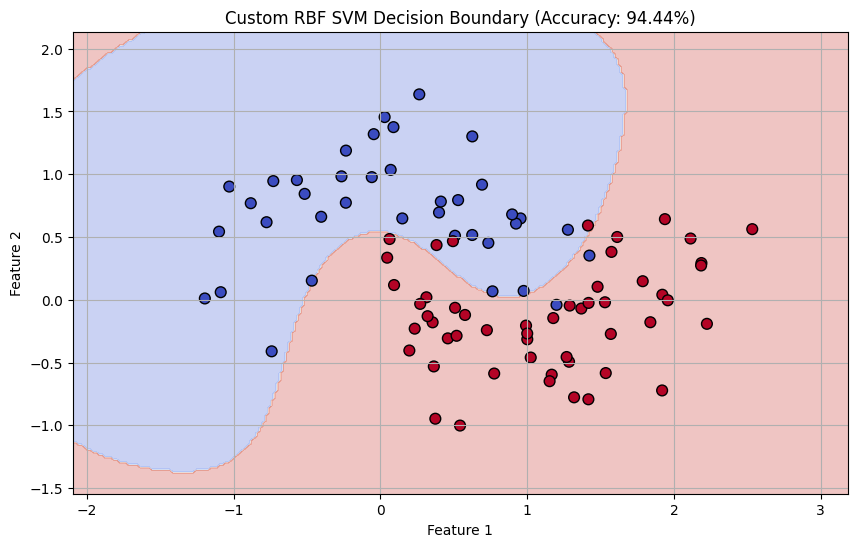

In [9]:
import matplotlib.pyplot as plt

# 1. Initialize our custom SVM with the RBF Kernel function we wrote
# Gamma controls how tightly the boundary wraps around data points
rbf_kernel = SVMKernels.rbf(gamma=1.5)
my_svm = CustomSVM(learning_rate=0.001, lambda_param=0.001, n_iters=500, kernel_func=rbf_kernel)

# 2. Train the SVM model on our Moons training data
print("Training custom RBF SVM (this might take a few seconds)...")
my_svm.fit(X_train, y_train)

# 3. Test its accuracy on the unseen test data
svm_preds = my_svm.predict(X_test)
svm_accuracy = np.mean(svm_preds == y_test) * 100
print(f"Custom RBF SVM Model Accuracy: {svm_accuracy:.2f}%")

# 4. Create a dense grid to visualize the decision boundary lines
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# 5. Predict the class for every single point on the grid map
grid_points = np.c_[xx.ravel(), yy.ravel()]
Z = my_svm.predict(grid_points)
Z = Z.reshape(xx.shape)

# 6. Plot everything!
plt.figure(figsize=(10, 6))
# Draw the colored decision background regions
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
# Draw the actual data points from our testing set
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='coolwarm', edgecolors='k', s=60)

plt.title(f"Custom RBF SVM Decision Boundary (Accuracy: {svm_accuracy:.2f}%)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.show()